In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

print("Import erfolgreich")

Import erfolgreich


In [2]:
# Normale Maschinendaten
np.random.seed(42)
normal = np.random.normal(loc=85, scale=3, size=200)

# Anomalien hinzufügen
anomalien = np.array([110, 115, 45, 120, 40])

# Kombinieren
daten = np.concatenate([normal, anomalien])
df = pd.DataFrame({"temperatur": daten})

print(f"Datenpunkte gesamt: {len(df)}")
print(f"Davon Anomalien: {len(anomalien)}")

Datenpunkte gesamt: 205
Davon Anomalien: 5


In [3]:
# Isolation Forest trainieren
modell = IsolationForest(contamination=0.02, random_state=42)
df["vorhersage"] = modell.fit_predict(df[["temperatur"]])

# -1 = Anomalie, 1 = Normal
df["label"] = df["vorhersage"].map({1: "Normal", -1: "Anomalie"})

print(df["label"].value_counts())
print("\nGefundene Anomalien:")
print(df[df["label"] == "Anomalie"]["temperatur"].values)

label
Normal      200
Anomalie      5
Name: count, dtype: int64

Gefundene Anomalien:
[110. 115.  45. 120.  40.]


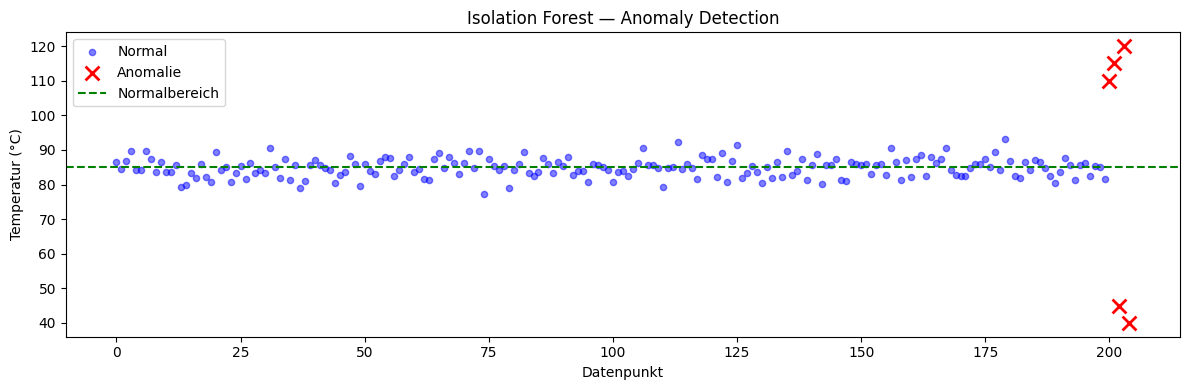

In [4]:
# Anomalien plotten
normal_data = df[df["label"] == "Normal"]
anomalie_data = df[df["label"] == "Anomalie"]

plt.figure(figsize=(12, 4))
plt.scatter(normal_data.index, normal_data["temperatur"],
            color="blue", label="Normal", alpha=0.5, s=20)
plt.scatter(anomalie_data.index, anomalie_data["temperatur"],
            color="red", label="Anomalie", s=100, marker="x", linewidths=2)
plt.axhline(y=85, color="green", linestyle="--", label="Normalbereich")
plt.title("Isolation Forest — Anomaly Detection")
plt.xlabel("Datenpunkt")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.tight_layout()
plt.show()